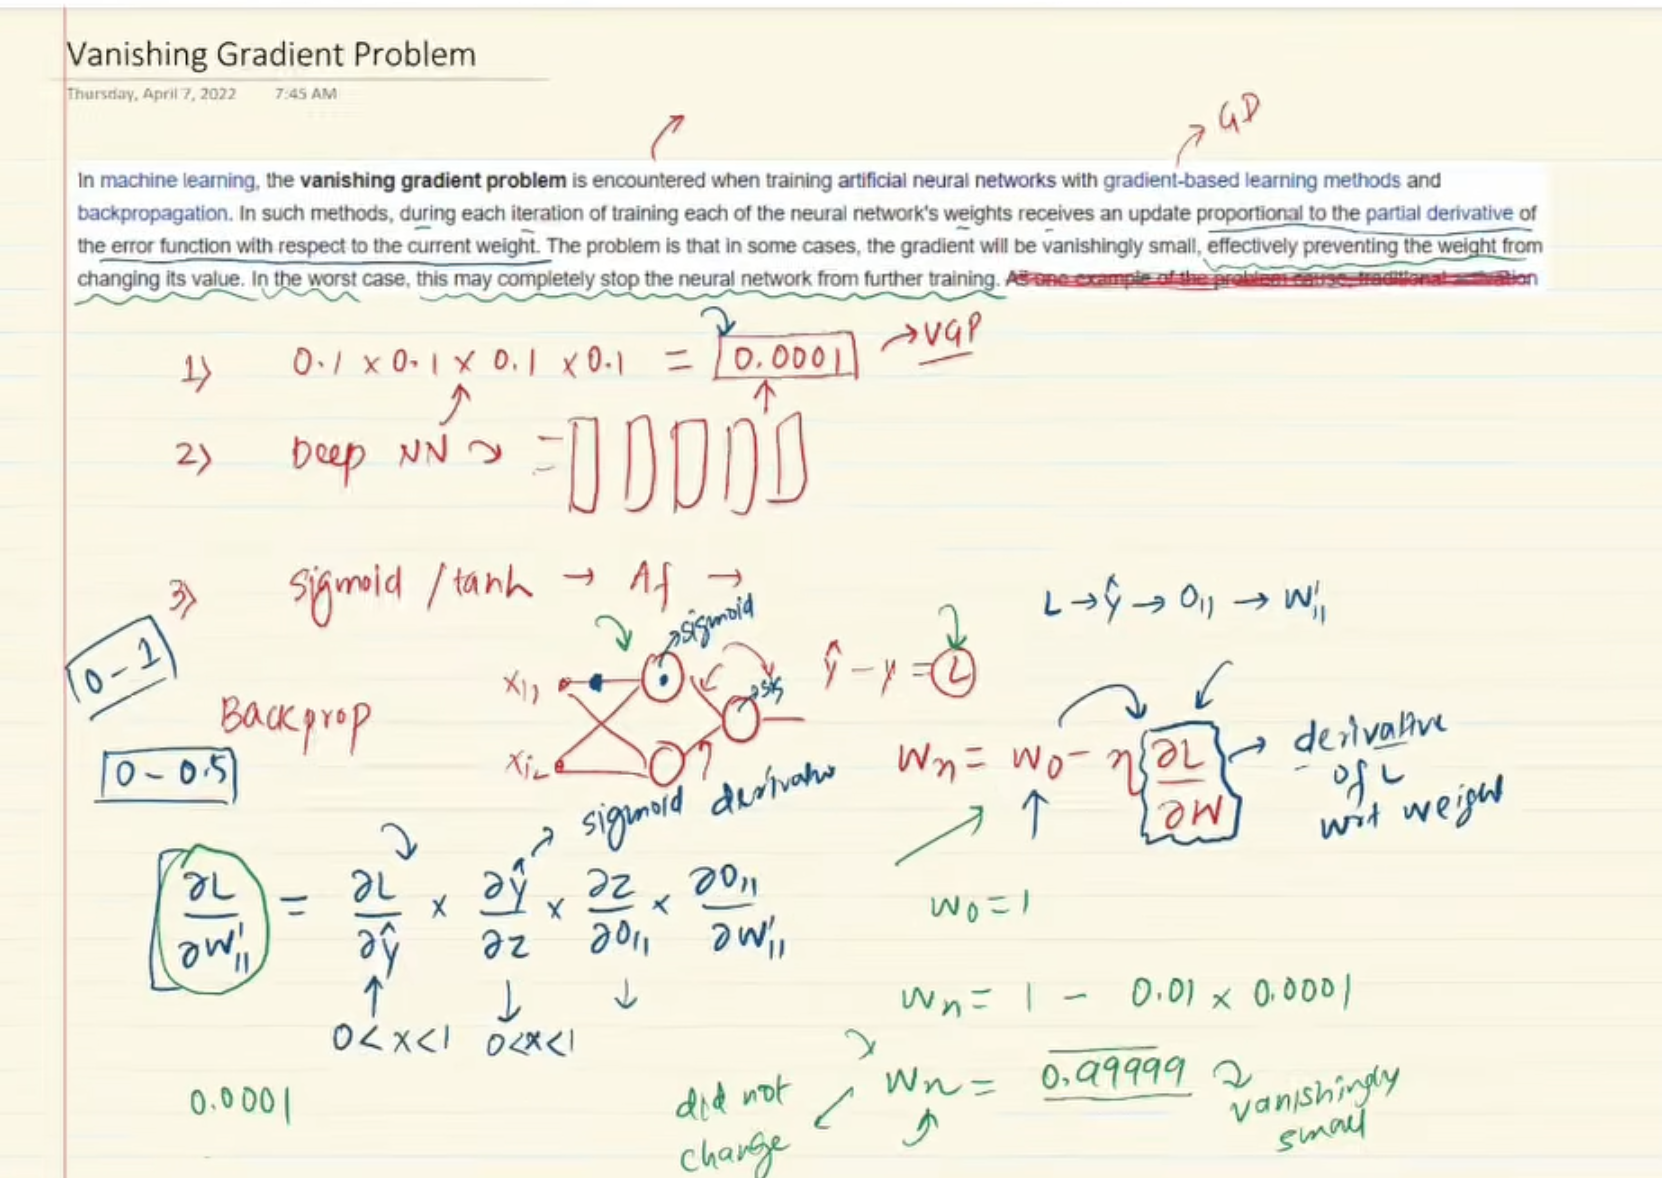

## Topic 1: Vanishing Gradient Problem – Introduction & Core Concept

### 1. Introduction

**What is the Vanishing Gradient Problem?**
A training issue in deep neural networks where the gradients (update signals) become extremely small as they propagate backwards through the network. This causes the early layers to learn very slowly or stop learning entirely.

**Why is it important?**
- Commonly asked in interviews
- If this problem occurs, your neural network cannot train properly
- Was a major obstacle that prevented deep networks from working well in the early days of deep learning

**Real-life use / Analogy:**
Imagine a game of "telephone" where a message passes through 100 people. By the time it reaches the first person, the message has faded to almost nothing. Similarly, the "learning signal" fades as it moves backward through many layers.

---

### 2. Detailed Explanation

#### The Core Mathematical Principle

The vanishing gradient problem is based on a simple mathematical fact:

> **When you multiply many numbers that are all less than 1, the product becomes much smaller than any of the individual numbers.**

| Example | Numbers (all <1) | Product | Result |
|---------|----------------|---------|--------|
| 3 numbers | 0.5 × 0.5 × 0.5 | 0.125 | Smaller than each |
| 10 numbers | 0.5¹⁰ | ~0.00098 | Extremely small |

#### How This Applies to Neural Networks

In a **deep neural network** (many layers, e.g., 8–10+ layers):

1. **Backpropagation algorithm** calculates gradients by multiplying derivatives at each layer
2. Each derivative is typically between **0 and 0.5** (especially with certain activation functions like Sigmoid or Tanh)
3. Multiplying many such small numbers → **extremely tiny gradient**

#### What Happens as a Result?

**Weight Update Formula:**
```
New Weight = Old Weight - (Learning Rate × Gradient)
```

If the **gradient is extremely small** (e.g., 0.0000001):
- Weight change is negligible
- Weight practically doesn't change
- No learning occurs
- Loss (error) stays the same

> **"In the worst case, the network stops learning completely"**

#### Visualizing the Effect

```
Layer 1 (early)  ←  Layer 2  ←  Layer 3  ←  Layer 4 (late)
     ↑                  ↑           ↑            ↑
  Tiny gradient    Small grad   Medium grad   Normal grad
  (almost no       (little      (some         (updates
   learning)        learning)    learning)      properly)
```

The **first layers** receive the smallest gradients → they learn the slowest or not at all.

#### Why Did This Problem Delay Deep Learning?

Before modern solutions, most activation functions were **Sigmoid** or **Tanh** – both "squashing functions" that compress any input into a small range (0 to 1, or -1 to 1). This squeezing creates small derivatives → vanishing gradients.

---

### 3. Key Points

| # | Key Point |
|---|-----------|
| 1 | Vanishing gradient = gradients become extremely small during backpropagation |
| 2 | Caused by multiplying many numbers that are **< 1** |
| 3 | Primarily affects **deep neural networks** (many layers) |
| 4 | Early layers learn very slowly or stop learning |
| 5 | Without weight changes, loss doesn't decrease |
| 6 | Problem is **activation function dependent** (Sigmoid/Tanh make it worse) |

---

### 7. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Thinking it affects all layers equally | Early layers are affected more because gradients travel further | Monitor first-layer weight changes separately |
| Ignoring the problem in shallow networks | Vanishing gradients mainly occur in deep networks (8–10+ layers) | For shallow networks (2–3 layers), this is rarely an issue |
| Confusing cause and effect | Small gradients are the *cause*, not the result of slow learning | Check gradients directly, not just loss |

---

### 8. Interview / Exam Questions

**Q1: What is the vanishing gradient problem in simple terms?**
> **A:** When you multiply many small numbers (derivatives < 1) together during backpropagation, the product becomes extremely small. This makes weight updates negligible, so early layers don't learn.

**Q2: Why does this problem affect deeper networks more?**
> **A:** Because more multiplications occur. Each additional layer adds one more derivative to multiply, making the product exponentially smaller.

**Q3: Which activation functions are most problematic for vanishing gradients?**
> **A:** Sigmoid and Tanh, because their derivatives are always between 0 and 0.5 (for Sigmoid) or 0 and 1 (for Tanh).

**Q4: What happens to the loss when vanishing gradients occur?**
> **A:** The loss stops decreasing after initial epochs because weights stop updating meaningfully.

---

### 9. Revision Notes

- **Vanishing gradient** = gradients become extremely small
- **Cause** = multiplying many numbers < 1
- **Effect** = early layers don't learn, loss doesn't decrease
- **Affects** = deep neural networks (many layers)
- **Worsened by** = Sigmoid/Tanh activation functions
- **Key formula**: New weight = Old weight – (LR × gradient)
- **If gradient ≈ 0** → New weight ≈ Old weight → no learning

---



## Topic 2: How to Detect the Vanishing Gradient Problem

### 1. Introduction

Before you can fix the vanishing gradient problem, you need to know how to **identify** that it's actually happening. The transcript provides two practical methods to detect this issue during training.

**Why detection matters:**
- You might waste time training a model that cannot learn
- Helps you decide which solution to apply
- Essential for debugging deep neural networks

---

### 2. Detailed Explanation

#### Method 1: Monitor the Loss Curve

**What to look for:**
- After initial training, the loss stops decreasing
- Loss remains flat (constant) over many epochs
- No meaningful improvement despite continued training

**Visual Representation:**
```
Loss
  |
  |  \_
  |    \_____  ← Loss decreases initially
  |          ‾‾‾‾‾‾‾‾‾ ← Then becomes flat (no change)
  |______________________ Epochs
```

**What it means:**
- If loss is not changing, weights are not updating
- If weights are not updating, gradients are near zero
- Near-zero gradients = vanishing gradient problem

#### Method 2: Plot Gradient Values Directly

**Better approach:** Graph the gradient values for each layer

**What to look for:**
- Gradients in early layers are extremely small (e.g., 1e-7, 1e-8)
- Gradients decrease as you move from later layers to earlier layers

```
Layer 4 (output): gradient = 0.5   ← Large
Layer 3:          gradient = 0.05  ← Smaller  
Layer 2:          gradient = 0.005 ← Much smaller
Layer 1 (input):  gradient = 0.0005 ← Tiny → PROBLEM!
```

#### Method 3: Compare Weight Updates Before and After Training

**What the transcript shows:**
Calculate the percentage change in weights:

```
Percentage Change = |Old Weight - New Weight| / |Old Weight| × 100
```

**Example from transcript:**

| Scenario | Old Weight | New Weight | Percentage Change | Verdict |
|----------|------------|------------|-------------------|---------|
| With vanishing gradient | 0.520 | 0.520 | ~0% (no change) | ❌ Problem |
| Normal training | 0.520 | 0.385 | ~26% change | ✅ Working |

**Observation from the demonstration:**
> "Look at my first layer's gradient... it is very very small. Percentage change is less than 1% - basically no change at all."

---

### 3. Key Points

| Detection Method | What to Check | Indicates Problem If... |
|-----------------|---------------|------------------------|
| Loss monitoring | Loss value over epochs | Loss flattens and stops decreasing |
| Gradient plotting | Gradient magnitude per layer | Early layer gradients are near zero (e.g., 1e-7) |
| Weight comparison | Old vs new weights | No significant change after training |
| Percentage change | (Δweight / old weight) × 100 | Change < 1% |

---

### 4. Code Example (from transcript)

The transcript shows this detection approach:

```python
# Step 1: Store initial weights BEFORE training
old_weights = model.get_weights()  # Save first layer weights

# Step 2: Train the model
model.fit(X_train, y_train, epochs=10)

# Step 3: Get weights AFTER training
new_weights = model.get_weights()

# Step 4: Calculate gradient using formula
# Gradient = (Old Weight - New Weight) / Learning Rate
gradient = (old_weights[0] - new_weights[0]) / learning_rate

# Step 5: Calculate percentage change
percentage_change = abs(old_weights[0] - new_weights[0]) / abs(old_weights[0]) * 100

# Step 6: Check if problem exists
if percentage_change < 1:
    print("Vanishing gradient detected - weights barely changed!")
```

**Line-by-Line Explanation:**

| Code | Purpose |
|------|---------|
| `model.get_weights()` | Captures weights before training (baseline) |
| `model.fit()` | Trains the model |
| `old - new` | Measures how much weights changed |
| `÷ learning_rate` | Back-calculates the gradient value |
| `percentage change < 1%` | Threshold for detecting vanishing gradient |

---

### 5. Output Example (from transcript)

**When vanishing gradient IS present:**
```
First layer gradient: 0.000000152  (extremely small)
Percentage change: 0.03%
Old weight: 0.520000
New weight: 0.519998  ← Almost identical!
```

**When vanishing gradient is NOT present (normal):**
```
First layer gradient: 0.35
Percentage change: 26%
Old weight: 0.520
New weight: 0.385  ← Significant change
```

---

### 6. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Only looking at final loss | Loss may decrease initially then plateau; you might miss the plateau | Plot loss at every epoch, look for flattening |
| Checking only later layers | Vanishing gradients affect EARLY layers most | Always check first 1-2 layers |
| Assuming loss decrease = no problem | Loss might decrease from other layers while early layers still vanish | Check layer-specific gradients |
| Using absolute change without percentage | A change of 0.001 might be large for a small weight but tiny for a large one | Always calculate percentage change |

---

### 7. Interview / Exam Questions

**Q1: How can you detect if a neural network is suffering from vanishing gradients?**

> **A:** Three main ways: (1) Loss stops decreasing after initial training, (2) Plotting gradients shows extremely small values in early layers (e.g., 1e-7), (3) Comparing weights before and after training shows negligible percentage change (<1%).

**Q2: Why is monitoring only loss not always sufficient for detection?**

> **A:** Loss might still decrease slightly due to later layers updating, while early layers suffer from vanishing gradients. You need to check layer-specific gradients or weight changes.

**Q3: What does a percentage change of 0.03% in first-layer weights indicate?**

> **A:** It indicates a vanishing gradient problem. The weights barely changed, meaning the gradients were extremely small, so learning isn't happening in those early layers.

**Q4: If gradients in layer 4 are 0.5, layer 3 are 0.05, layer 2 are 0.005, and layer 1 are 0.0005 – what problem does this pattern show?**

> **A:** Vanishing gradient problem. The gradient magnitude decreases exponentially as you move from output layer (layer 4) to input layer (layer 1), showing the multiplication effect of many small derivatives.

---

### 8. Revision Notes

- **Detection Method 1:** Loss flattens → no learning happening
- **Detection Method 2:** Plot gradients → early layers show tiny values (1e-7 range)
- **Detection Method 3:** Compare weights → percentage change < 1% = problem
- **Formula:** Gradient = (Old − New) ÷ Learning Rate
- **Key symptom:** First layer weights barely change after many epochs
- **Visual cue:** Gradient values decrease exponentially from output to input

---




## Topic 3: Solutions to the Vanishing Gradient Problem – Part 1 (Model Complexity & Activation Functions)

The transcript presents **5 techniques** to solve the vanishing gradient problem. This response covers the first two solutions:

1. Reduce model complexity
2. Use different activation functions (specifically ReLU)

---

### 1. Introduction

**What these solutions do:**
They address the root cause of vanishing gradients—multiplying many small numbers—by either reducing how many multiplications happen or ensuring the numbers being multiplied aren't always small.

**Real-life analogy:**
- **Reduce complexity** = Shorter telephone line (fewer people to pass the message through)
- **Change activation function** = Use a megaphone instead of whispering (signal doesn't fade)

---

### 2. Detailed Explanation

#### Solution #1: Reduce Model Complexity

**What it means:**
Make your neural network less deep—reduce the number of layers.

**Why it works:**
- Fewer layers = fewer derivatives to multiply
- Each additional layer multiplies one more number (derivative)
- With fewer multiplications, the product doesn't become as tiny

**Comparison:**
| Network Depth | Number of Multiplications | Vanishing Risk |
|---------------|--------------------------|----------------|
| 100 layers | 99 derivative multiplications | Very high |
| 10 layers | 9 derivative multiplications | Moderate |
| 3 layers | 2 derivative multiplications | Low |

**Visual:**
```
Deep network (problem):      Shallow network (fixed):
Input → L1 → L2 → L3 → ... → L100 → Output    Input → L1 → L2 → L3 → Output
        ↑                      ↑                    ↑    ↑    ↑
        Very tiny gradient     Normal              Small Normal
        (problem!)             gradient            gradients
```

**Important Trade-off (from transcript):**
> "This method will work but it's not always applicable because the reason you use neural networks is for complexity... if you reduce complexity, you lose the ability to model complex patterns."

**When to use this approach:**
- Your data doesn't have highly complex, non-linear patterns
- You're prototyping and want to quickly test if vanishing gradients are the issue
- Model performance is acceptable with fewer layers

**From the code demonstration:**
The transcript shows that reducing from a very deep network (many layers) to a simpler architecture caused:
- Loss decreased properly from ~78.3 down (not stuck)
- Weight changes became visible and significant
- Gradients were no longer near-zero

#### Solution #2: Use Different Activation Functions (ReLU)

**What is ReLU?**
**ReLU** = Rectified Linear Unit

**Formula:**
```
ReLU(x) = max(0, x)
```

**What it does:**
- If input is **negative** → output is **0**
- If input is **positive** → output is **the same value** (identity)

**Graph:**
```
Output
  |
  |     /
  |    /
  |   /
  |  /
  | /
  |/___________ Input
  0
```

**Why ReLU solves vanishing gradients:**

| Activation | Derivative Range | Problem |
|------------|-----------------|---------|
| Sigmoid | 0 to 0.25 (always <1) | Multiplied → gets smaller |
| Tanh | 0 to 1 (≤1) | Can vanish if <1 |
| **ReLU** | **0 OR 1** | Either stops signal (0) or passes it unchanged (1) |

**Key insight:**
- When ReLU is positive, derivative = **1** (not a small number!)
- Multiplying by 1 doesn't shrink the gradient
- When derivative = 1, gradient doesn't vanish as it backpropagates

**But ReLU has its own problem (mentioned in transcript):**
> "There are problems with ReLU as well... if the activation becomes negative, derivative becomes 0, then the gradient dies completely" – this is called the **"Dying ReLU Problem"**

**What happens with ReLU (from demonstration):**

The transcript shows code results after switching to ReLU:

| Metric | With Sigmoid | With ReLU |
|--------|--------------|-----------|
| Gradient values | Extremely small | Negative values at some places, positive at others (no longer uniformly tiny) |
| Percentage change | <1% | 5%, 12%, 26% at different places |
| Weight update | No meaningful change | Significant changes |
| Loss reduction | Stuck | Properly decreasing |

**Demonstration results:**
> "Look at my gradient... gradient values are negative at some places, positive at some places... 5% change, 12% change, 26% change... vanishing gradient problem is NOT happening here!"

---

### 3. Key Points

| Solution | How It Works | Trade-off |
|----------|--------------|-----------|
| Reduce complexity (fewer layers) | Fewer derivative multiplications | May not capture complex patterns |
| Use ReLU activation | Derivative = 1 (not <1) so gradients don't shrink | Dying ReLU problem (neurons can "die" and output 0 always) |

**Rule of thumb from transcript:**
> "If your data's complexity is not that non-linear, you can reduce the number of layers."

---

### 4. Code Example (Switching to ReLU)

```python
# INSTEAD OF (problematic for deep networks):
model.add(Dense(128, activation='sigmoid'))

# USE THIS (better for deep networks):
model.add(Dense(128, activation='relu'))

# Complete example from transcript concept:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Output layer still uses sigmoid for binary classification
```

**Line-by-line explanation:**
| Code | Purpose |
|------|---------|
| `activation='relu'` | Tells each layer to use ReLU instead of sigmoid/tanh |
| Hidden layers use ReLU | Prevents gradient from shrinking during backpropagation |
| Output layer uses sigmoid | Still needed for probability outputs (0-1 range) |

---

### 5. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Reducing complexity too much | Model underfits and can't learn data patterns | Gradually reduce layers; check validation performance |
| Using ReLU everywhere | Output layer may need sigmoid/softmax for probability outputs | Keep ReLU for hidden layers only |
| Thinking ReLU always solves it | ReLU can cause "dying neurons" (always output 0) | Try Leaky ReLU or ELU as alternatives |
| Not monitoring after change | Problem may be reduced but not eliminated | Re-check gradient magnitudes after switching to ReLU |

---

### 6. Interview / Exam Questions

**Q1: Name two ways to solve the vanishing gradient problem.**

> **A:** (1) Reduce model complexity by using fewer layers. (2) Use ReLU activation function instead of Sigmoid or Tanh.

**Q2: Why does ReLU help with vanishing gradients?**

> **A:** When input is positive, ReLU's derivative is exactly 1, not a fraction like sigmoid (max 0.25). Multiplying by 1 doesn't shrink the gradient during backpropagation.

**Q3: What is the trade-off of reducing model complexity to fix vanishing gradients?**

> **A:** You lose the ability to model complex, non-linear patterns in the data. The model may underfit if the data requires depth.

**Q4: What problem can ReLU introduce instead of vanishing gradients?**

> **A:** The "Dying ReLU Problem" – when input is negative, output is 0 and derivative is 0, so the neuron stops learning entirely.

**Q5: From the transcript's demonstration, what percentage change in weights was observed after switching to ReLU?**

> **A:** 5%, 12%, and 26% changes at different places, compared to less than 1% with sigmoid.

---

### 7. Revision Notes

**Solution #1 – Reduce Complexity:**
- Fewer layers = fewer gradient multiplications
- Trade-off: may lose ability to model complex patterns
- Works but not always applicable

**Solution #2 – ReLU Activation:**
- Formula: ReLU(x) = max(0, x)
- Derivative = 1 when x > 0 (doesn't shrink gradients)
- Derivative = 0 when x < 0 (dying ReLU problem)
- Use for hidden layers; keep sigmoid/softmax for output

**Quick comparison:**
| | Sigmoid | ReLU |
|---|---------|------|
| Derivative range | 0 to 0.25 | 0 or 1 |
| Vanishing risk | High | Low |
| Dying risk | None | Possible |

---



## Topic 4: Solutions to the Vanishing Gradient Problem – Part 2 (Batch Normalization, Gradient Clipping & Residual Networks)

This response covers the remaining **3 solutions** mentioned in the transcript:

1. Batch Normalization
2. Gradient Clipping (also used for Exploding Gradients)
3. Residual Networks (ResNets)

---

### 1. Introduction

These three techniques represent more advanced solutions to the vanishing gradient problem. The transcript notes that these will be covered in detail in future videos, but provides an overview of what they are and why they work.

**Why these matter:**
- They allow training of **very deep networks** (100+ layers) without vanishing gradients
- They address the root causes more elegantly than simply reducing layers
- Used in state-of-the-art deep learning architectures

---

### 2. Detailed Explanation

#### Solution #3: Batch Normalization

**What it is:**
A technique that normalizes the inputs to each layer during training, ensuring they have consistent mean and variance.

**Why it helps with vanishing gradients:**
- Prevents activations from becoming too small (which would create small derivatives)
- Keeps values in a reasonable range where activation functions have meaningful gradients
- Reduces internal covariate shift (the problem of layer inputs changing during training)

**How it works (briefly):**
```
Input to layer → Normalize (subtract mean, divide by std dev) → Scale & shift → Pass to activation function
```

**From the transcript:**
> "Batch normalization... even by using this we can solve the vanishing gradient problem."

**What the transcript promises for future coverage:**
> "We will discuss properly in a series on normalization, its new techniques, but even by using that we can solve the vanishing gradient problem."

---

#### Solution #4: Gradient Clipping

**What it is:**
A technique that caps gradients at a maximum value during backpropagation.

**Primary use:**
While this is **mainly for exploding gradients**, the transcript mentions it as part of the 5-solution framework.

**How it works:**
```
If gradient > threshold:
    gradient = threshold
If gradient < -threshold:
    gradient = -threshold
```

**Example:**
```python
# Conceptual code
max_norm = 1.0
if gradient > max_norm:
    gradient = max_norm
```

**From the transcript:**
> "Using techniques like gradient clipping, we can avoid [the exploding gradient] problem."

---

#### Solution #5: Residual Networks (ResNets / Residual Blocks)

**What it is:**
A neural network architecture that uses "skip connections" – paths that bypass one or more layers.

**Why it solves vanishing gradients:**

**Traditional network (no skip connections):**
```
Input → Layer 1 → Layer 2 → Output
        ↓         ↓
      Gradient multiplies through both layers
```

**Residual network (with skip connection):**
```
Input → Layer 1 → Layer 2 → Output
  |_________________↑
       Skip connection (bypasses layers)
```

**Key insight from transcript:**
> "Residual blocks have a special property that you can use in your artificial neural network. They help solve the vanishing gradient problem."

**Why skip connections work:**
- Gradients have an alternative path to flow back to early layers
- They don't have to multiply through every layer
- Even if the main path gradients vanish, the skip connection provides a direct gradient highway

**Visual representation:**
```
Without skip connections:          With skip connections:
Gradient flow:                      Gradient flow:
Output ← L3 ← L2 ← L1 ← Input       Output ← L3 ← L2 ← L1 ← Input
        (multiplies at each step)        ↑_________________↑
                                          (direct path, no multiplication)
```

---

### 3. Key Points – All 5 Solutions Summary

| # | Solution | How It Solves Vanishing Gradients | When to Use |
|---|----------|-----------------------------------|-------------|
| 1 | Reduce complexity | Fewer derivative multiplications | Simple data, quick prototyping |
| 2 | ReLU activation | Derivative = 1 (doesn't shrink) | Most deep networks by default |
| 3 | Batch normalization | Keeps activations in healthy range | Training very deep networks |
| 4 | Gradient clipping | Caps extreme values (mainly for exploding) | When gradients become too large |
| 5 | Residual networks | Skip connections provide direct gradient paths | State-of-the-art deep architectures |

---

### 4. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Using all solutions at once unnecessarily | Adds computational overhead; may overcomplicate | Start with ReLU; add others only if problem persists |
| Confusing gradient clipping (for exploding) with vanishing solutions | Clipping doesn't fix vanishing; it fixes exploding | For vanishing, use ReLU, ResNets, or batch norm first |
| Implementing residual blocks incorrectly | Skip connections must be properly dimensioned | Ensure skip connection and main path outputs have same shape |
| Adding batch norm without understanding | May not help if placed incorrectly | Put batch norm BEFORE activation function (usually) |

---

### 5. Interview / Exam Questions

**Q1: What are the five ways to solve the vanishing gradient problem mentioned in the video?**

> **A:** (1) Reduce model complexity, (2) Use ReLU activation function, (3) Batch normalization, (4) Gradient clipping, (5) Residual networks / residual blocks.

**Q2: How do residual networks (ResNets) help with vanishing gradients?**

> **A:** Skip connections provide an alternative path for gradients to flow back to early layers without having to multiply through every layer. This creates a "gradient highway" that preserves gradient magnitude.

**Q3: Is gradient clipping primarily for vanishing or exploding gradients?**

> **A:** Gradient clipping is primarily for **exploding gradients**. It caps large gradients to prevent them from becoming too big.

**Q4: Why is batch normalization effective against vanishing gradients?**

> **A:** It keeps layer inputs normalized (consistent mean and variance), preventing activations from becoming too small and ensuring derivatives stay within meaningful ranges.

**Q5: Which solution is mentioned as being able to allow training of very deep networks (100+ layers)?**

> **A:** Residual networks (ResNets) with skip connections allow training of extremely deep networks without vanishing gradients.

---

### 6. Revision Notes – All 5 Solutions

**Quick Reference Table:**

| Solution | One-line summary | Effectiveness |
|----------|-----------------|---------------|
| Reduce layers | Shorter path = less multiplication | Works but reduces capability |
| ReLU | Derivative = 1 (not small) | Standard approach |
| Batch norm | Keep values in good range | Very effective |
| Gradient clip | Cap extreme values | For exploding gradients |
| ResNets | Skip connections = gradient highway | State-of-the-art |

**From the transcript's closing summary:**
> "Reduce complexity if possible, use different activation functions like ReLU, use batch normalization, use gradient clipping, use residual networks – these five techniques."

---

### 7. What's Next in the Series (from transcript)

The transcript mentions upcoming videos will cover:
- Detailed explanation of batch normalization
- Gradient clipping implementation
- Residual networks in depth
- Exploding gradient problem (next topic)

---


## Topic 5: The Exploding Gradient Problem

### 1. Introduction

**What is the Exploding Gradient Problem?**
The opposite of the vanishing gradient problem. Instead of gradients becoming extremely small, they become **extremely large** during backpropagation.

**Why it's important:**
- Just as problematic as vanishing gradients
- Can cause model instability and training failure
- Often appears in recurrent neural networks (RNNs)
- Interviewers frequently ask about both problems together

**Real-life analogy:**
Instead of a whisper fading to nothing (vanishing), imagine a rumor that gets amplified each time it's passed along – "I heard 10 people attended" → "I heard 100 people attended" → "I heard 10,000 people attended" – eventually becoming nonsense.

---

### 2. Detailed Explanation

#### The Core Mathematical Principle

Exactly opposite to vanishing gradients:

> **When you multiply many numbers that are all greater than 1, the product becomes much larger than any of the individual numbers.**

| Example | Numbers (all >1) | Product | Result |
|---------|-----------------|---------|--------|
| 3 numbers | 2 × 2 × 2 | 8 | Larger than each |
| 5 numbers | 2⁵ | 32 | Much larger |
| 10 numbers | 2¹⁰ | 1,024 | Extremely large |

#### How This Applies to Neural Networks

During backpropagation, if derivatives are **greater than 1**:

1. Each derivative multiplication **amplifies** the gradient
2. With many layers, the gradient grows **exponentially**
3. Weight updates become **massive and random**

#### What Happens as a Result?

**Weight Update Formula (same as before):**
```
New Weight = Old Weight - (Learning Rate × Gradient)
```

If the **gradient is extremely large** (e.g., 10,000):
- Weight change is enormous
- Update overshoots the optimal value
- Model becomes unstable

**Consequences:**
| Effect | Description |
|--------|-------------|
| Weight explosion | Weights become NaN (Not a Number) or infinity |
| Random predictions | Model outputs become arbitrary |
| Loss won't decrease | Error doesn't improve |
| Training crash | Model becomes unusable |

#### Visual Comparison

```
Vanishing Gradients:               Exploding Gradients:
Gradient size:                     Gradient size:
Layer 4: 0.5                       Layer 4: 2.0
Layer 3: 0.05      (smaller)       Layer 3: 4.0      (larger)
Layer 2: 0.005     (smaller)       Layer 2: 8.0      (larger)
Layer 1: 0.0005    (tiny!)         Layer 1: 16.0     (huge!)

Result: Under-updates              Result: Over-updates
Model: Underfits                   Model: Unstable/NaN
```

#### Example from Transcript

The transcript provides this illustrative example:

> "If weight was 100 initially, and you multiply by gradients >1 repeatedly, it becomes 1,000, then 10,000, then 100,000 – weight grows out of control."

**Numerical example:**

| Starting Weight | After 1 update | After 2 updates | After 3 updates |
|-----------------|----------------|-----------------|-----------------|
| 1.0 | 1.0 - (0.01 × 100) = 0 | 0 - (0.01 × 10,000) = -100 | Instability |
| Or weight grows: 1 → 100 → 10,000 → NaN | | | |

---

### 3. Key Points

| # | Vanishing Gradient | Exploding Gradient |
|---|-------------------|-------------------|
| 1 | Gradients become too small | Gradients become too large |
| 2 | Multiples of numbers < 1 | Multiples of numbers > 1 |
| 3 | Weights barely change | Weights change wildly |
| 4 | Model stops learning | Model becomes unstable |
| 5 | Loss stays flat | Loss may become NaN |

**From the transcript:**
> "Exploding gradient problem – principle is exactly opposite. If you have numbers greater than 1 and multiply them, the product becomes huge. Your weight update goes to a very large number – 1,000, 10,000 – and your model stops training."

---

### 4. How to Detect Exploding Gradients

| Detection Method | What to Look For |
|-----------------|------------------|
| Loss values | Loss becomes NaN (Not a Number) or infinity |
| Weights | Weights become extremely large (e.g., > 1e10) |
| Gradients | Gradient magnitudes exceed 100, 1000, or more |
| Model outputs | Predictions become random or constant extremes |

**Code detection concept:**
```python
# Check for exploding gradients
if any(np.isnan(gradient) for gradient in gradients):
    print("Exploding gradient detected - NaN values present")
if any(np.max(np.abs(gradient)) > 100 for gradient in gradients):
    print("Exploding gradient detected - values too large")
```

---

### 5. Solutions to Exploding Gradients

The transcript mentions one primary solution:

#### Gradient Clipping

**What it does:** Caps gradients at a maximum threshold before they cause damage.

**How it works:**
```python
# Conceptual code
clip_value = 1.0
gradients = np.clip(gradients, -clip_value, clip_value)
```

**Types of gradient clipping:**

| Type | How It Works |
|------|--------------|
| Value clipping | Cap each gradient value individually (e.g., between -1 and 1) |
| Norm clipping | Scale gradients so their norm doesn't exceed a threshold |

**From the transcript:**
> "Using techniques like gradient clipping, we can avoid the exploding gradient problem."

**Other solutions (common in practice but not in this transcript):**
- Lower learning rate
- Weight regularization (L1/L2)
- Gradient normalization

---

### 6. Comparison Table: Vanishing vs Exploding

| Aspect | Vanishing Gradient | Exploding Gradient |
|--------|-------------------|-------------------|
| **Cause** | Multiplying numbers < 1 | Multiplying numbers > 1 |
| **Gradient size** | Very small (~1e-7) | Very large (>100) |
| **Weight change** | Almost none | Huge, random |
| **Loss behavior** | Stays flat | Becomes NaN or infinity |
| **Model outcome** | Underfits / doesn't learn | Unstable / crashes |
| **Common in** | Deep networks with sigmoid/tanh | RNNs, deep networks with large weights |
| **Primary solution** | ReLU, ResNets, batch norm | Gradient clipping |

---

### 7. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Confusing vanishing with exploding | Solutions are different (ReLU helps vanishing; clipping helps exploding) | Check gradient magnitudes first |
| Using gradient clipping for vanishing | Clipping doesn't fix small gradients | Use ReLU or reduce complexity |
| Setting clip value too low | May prevent legitimate large updates | Try values like 1.0, 5.0 and monitor |
| Not detecting early | Once weights become NaN, training is lost | Monitor gradients during training, use callbacks |

---

### 8. Interview / Exam Questions

**Q1: What is the exploding gradient problem?**

> **A:** When gradients become extremely large during backpropagation because many derivatives greater than 1 are multiplied together. This causes massive weight updates, model instability, and often results in NaN values.

**Q2: How is the exploding gradient problem different from the vanishing gradient problem?**

> **A:** Vanishing gradients come from multiplying numbers < 1 (gradients shrink to zero). Exploding gradients come from multiplying numbers > 1 (gradients grow to infinity). Vanishing causes under-updating; exploding causes over-updating and instability.

**Q3: What is the primary solution to exploding gradients mentioned in the transcript?**

> **A:** Gradient clipping – capping gradients at a maximum threshold to prevent them from becoming too large.

**Q4: What would you see in your training logs if exploding gradients occurred?**

> **A:** Loss values might become NaN (Not a Number) or infinity. Weights might show extremely large numbers. The model may stop producing sensible predictions.

**Q5: Which type of neural network is particularly prone to exploding gradients?**

> **A:** Recurrent Neural Networks (RNNs), though the transcript notes it can occur in deep networks in general.

---

### 9. Revision Notes

**Exploding Gradients – Quick Recap:**

- **Definition:** Gradients become extremely large during backpropagation
- **Cause:** Multiplying many numbers > 1
- **Effect:** Weight updates are massive and random; model becomes unstable
- **Detection:** Loss becomes NaN; weights grow to extreme values
- **Primary solution:** Gradient clipping

**Comparison Reminder:**
```
Vanishing: 0.5 × 0.5 × 0.5 = 0.125 (gets smaller)
Exploding: 2.0 × 2.0 × 2.0 = 8.0 (gets larger)
```

**One-line takeaways:**
> "Vanishing = gradients too small → model doesn't learn. Exploding = gradients too large → model crashes."

---
